In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [8]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

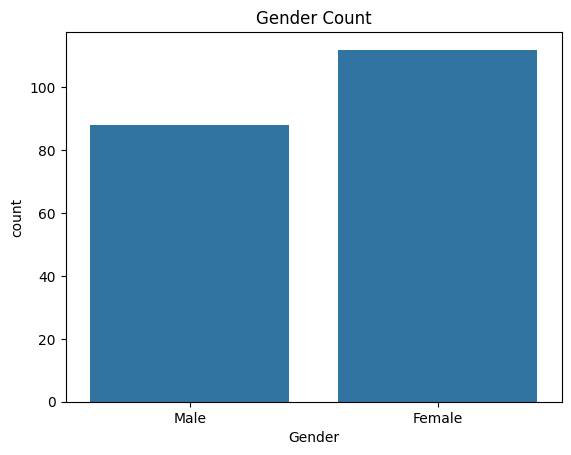

In [11]:
sns.countplot(x='Gender', data=df)
plt.title('Gender Count')
plt.show()

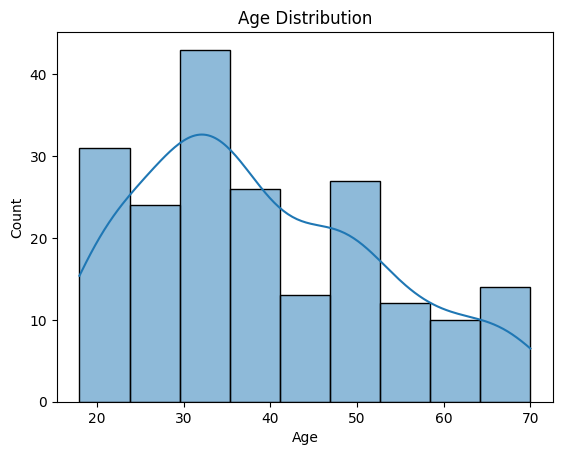

In [12]:
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

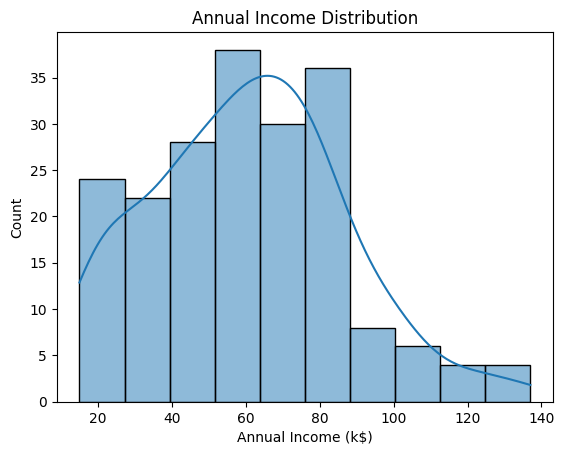

In [13]:
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.title('Annual Income Distribution')
plt.show()

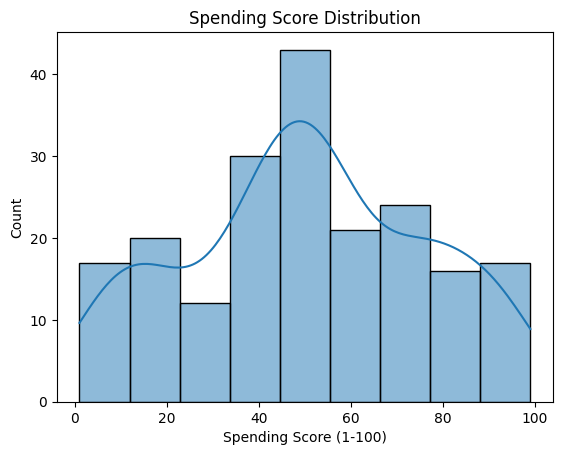

In [14]:
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title('Spending Score Distribution')
plt.show()

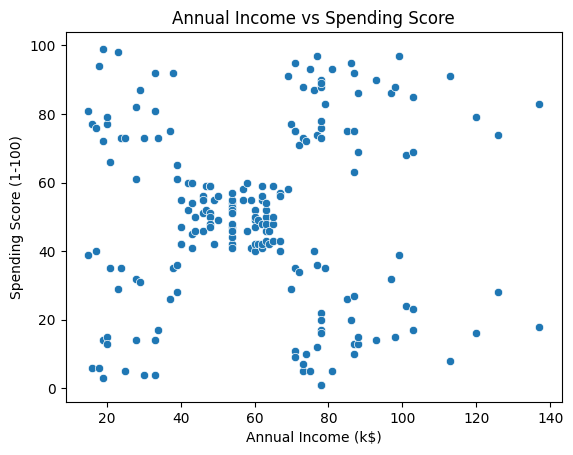

In [15]:
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title('Annual Income vs Spending Score')
plt.show()

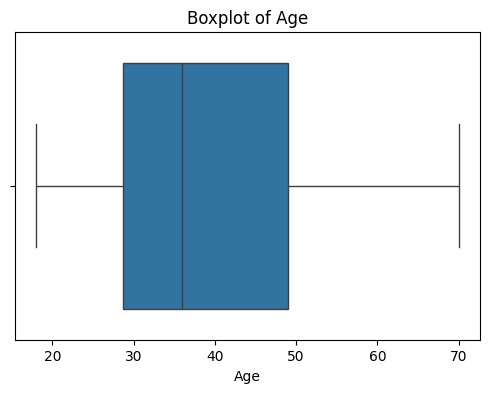

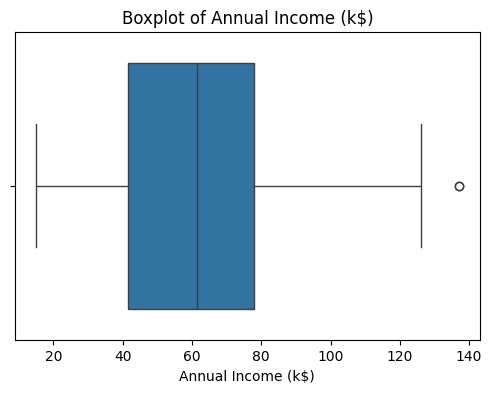

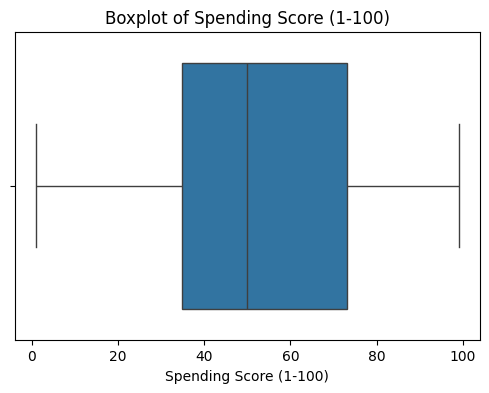

In [16]:
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [17]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outlier_count = df[(df[col] < lower_limit) | (df[col] > upper_limit)].shape[0]
    print(col, ":", outlier_count, "outliers")

Age : 0 outliers
Annual Income (k$) : 2 outliers
Spending Score (1-100) : 0 outliers


In [18]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_limit, lower_limit, df[col])
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

In [19]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

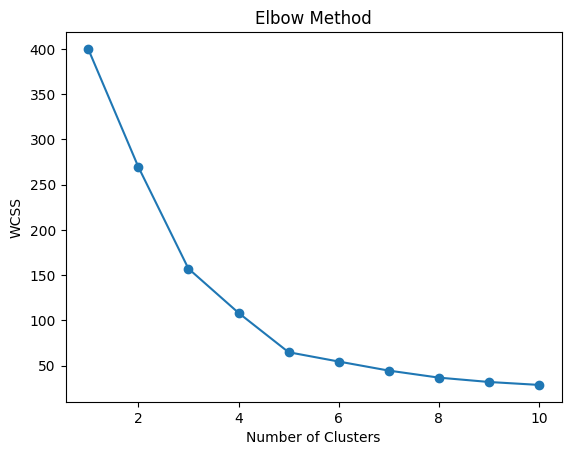

In [21]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [22]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [23]:
df['Cluster'] = clusters
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19.0,15.0,39.0,4
1,2,Male,21.0,15.0,81.0,2
2,3,Female,20.0,16.0,6.0,4
3,4,Female,23.0,16.0,77.0,2
4,5,Female,31.0,17.0,40.0,4


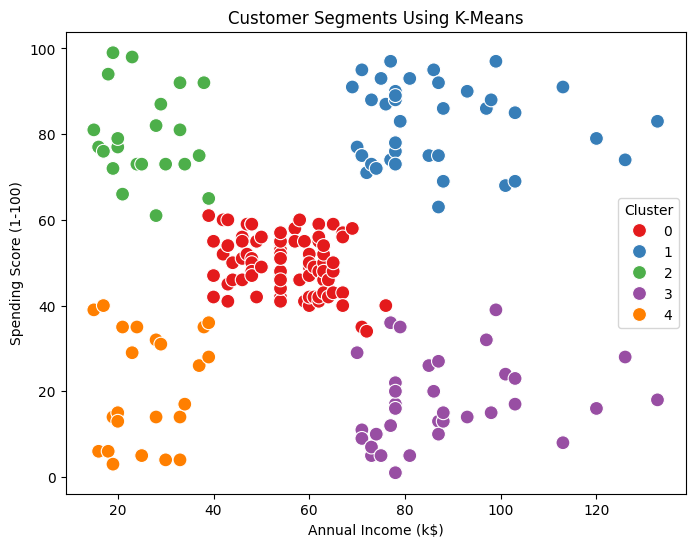

In [24]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100
)

plt.title('Customer Segments Using K-Means')
plt.show()

In [25]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)

centers_df

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.429487,82.128205
2,25.727273,79.363636
3,88.078571,17.114286
4,26.304348,20.913043


In [26]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.5555014501078793


In [27]:
df.to_csv("mall_customers_clustered.csv", index=False)